# Algoritmo Genético N-Queens (versão básica)

In [1]:
%pip install numpy matplotlib

import random
import time
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [2]:
n = 8
m = 50
geracoes = 50
taxa_mutacao = 0.05

In [3]:
def imprime_matriz(matriz):
    for i in range(matriz.shape[0]):
        if i < 9:
            print(f' {[i+1]} ', end='')
        else:
            print(f'{[i+1]} ', end='')
        for j in range(matriz.shape[1]):
            print(matriz[i][j], end=' ')
        print()

def imprime_conflitos(conflitos):
    for i in range(conflitos.shape[0]):
        if i < 9:
            print(f' {[i+1]} ', end='')
        else:
            print(f'{[i+1]} ', end='')
        print(conflitos[i][0])

def gerar_populacao(m, n):
    matriz = np.zeros((m, n), dtype=int)
    for i in range(m):
        for j in range(n):
            matriz[i][j] = random.randint(1, n)
    return matriz


def verifica_conflitos(matriz):

    conflitos = np.zeros((matriz.shape[0], 1), dtype=int)

    # verifica conflitos para cada indivíduo
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            for k in range(j + 1, matriz.shape[1]):

                # conflito na mesma coluna
                if matriz[i][k] == matriz[i][j]:
                    conflitos[i] += 1

                # conflito na diagonal
                if abs(j - k) == abs(matriz[i][j] - matriz[i][k]):
                    conflitos[i] += 1

    return conflitos, conflitos.sum()


def seleciona_pai_binario(conflitos):
    
    # seleciona dois indivíduos aleatórios
    pai_01_index = random.randint(0, len(conflitos) - 1)
    pai_02_index = random.randint(0, len(conflitos) - 1)

    # garante que os dois indivíduos selecionados sejam diferentes
    while pai_02_index == pai_01_index:
        pai_02_index = random.randint(0, len(conflitos) - 1)

    if conflitos[pai_01_index][0] < conflitos[pai_02_index][0]:
        return pai_01_index
    else:
        return pai_02_index


def cruzamento(pai_01, pai_02, ponto_corte):

    # gera dois filhos a partir de dois pais e um ponto de corte
    filho_01 = np.concatenate((pai_01[:ponto_corte], pai_02[ponto_corte:]))
    filho_02 = np.concatenate((pai_02[:ponto_corte], pai_01[ponto_corte:]))

    return filho_01, filho_02


def mutacao(filho, taxa, n):
    
    # mutação simples que altera um gene aleatório do filho com uma nova posição aleatória
    if random.random() < taxa:
        posicao = random.randint(0, len(filho) - 1)
        novo_valor = random.randint(1, n)

        while novo_valor == filho[posicao]:
            novo_valor = random.randint(1, n)

        filho[posicao] = novo_valor

    return filho

def imprime_tabuleiro(individuo):
    n = len(individuo)
    print("\nTABULEIRO DA MELHOR SOLUÇÃO:\n")

    for linha in range(1, n + 1):
        for coluna in range(n):
            if individuo[coluna] == linha:
                print(" Q ", end="")
            else:
                print(" . ", end="")
        print()

In [4]:
# apenas teste para verificar se a geração da população inicial e a contagem de conflitos estão funcionando corretamente

matriz_ind_inicial = gerar_populacao(m, n)

print("POPULAÇÃO INICIAL:\n")
imprime_matriz(matriz_ind_inicial)

conflitos, qtdd_conflitos_inicial = verifica_conflitos(matriz_ind_inicial)

print(f"\nQuantidade total de conflitos inicial: {qtdd_conflitos_inicial}")
print("\nConflitos por indivíduo:")
imprime_conflitos(conflitos)

POPULAÇÃO INICIAL:

 [1] 4 6 4 6 8 2 7 8 
 [2] 7 3 7 4 1 5 1 5 
 [3] 2 4 2 8 1 3 6 6 
 [4] 4 2 3 8 8 6 8 8 
 [5] 3 6 4 3 3 3 2 7 
 [6] 3 1 8 1 7 5 6 4 
 [7] 3 4 5 5 5 7 4 8 
 [8] 3 1 1 3 7 2 8 7 
 [9] 1 8 3 6 4 4 4 8 
[10] 1 3 7 7 4 6 3 1 
[11] 8 5 3 6 4 1 3 2 
[12] 3 8 4 4 6 6 7 6 
[13] 5 8 1 3 7 6 4 5 
[14] 7 7 2 5 3 3 2 2 
[15] 8 5 2 3 2 2 2 8 
[16] 8 5 3 6 7 7 1 6 
[17] 7 8 8 3 7 3 6 4 
[18] 6 2 5 2 6 4 2 6 
[19] 3 7 2 6 1 8 1 5 
[20] 4 2 7 6 7 2 3 3 
[21] 7 1 7 3 2 3 3 6 
[22] 1 4 2 5 6 1 3 3 
[23] 8 5 2 3 6 7 4 7 
[24] 7 2 7 4 6 7 1 8 
[25] 8 5 3 1 3 1 2 8 
[26] 4 5 7 3 3 2 6 1 
[27] 2 4 8 1 8 1 5 2 
[28] 1 2 1 2 1 7 5 2 
[29] 7 3 3 5 2 6 7 1 
[30] 6 8 6 3 7 4 1 7 
[31] 1 7 8 4 3 8 8 5 
[32] 1 4 5 4 2 5 3 1 
[33] 4 1 8 1 4 2 6 4 
[34] 3 6 5 6 6 7 5 5 
[35] 8 7 4 1 5 7 2 7 
[36] 6 8 8 3 8 2 5 2 
[37] 2 5 8 7 5 6 1 6 
[38] 3 1 2 6 5 1 6 2 
[39] 4 1 7 5 1 7 5 3 
[40] 5 5 4 6 5 8 8 3 
[41] 4 5 8 2 5 6 7 7 
[42] 3 2 1 8 2 7 3 1 
[43] 8 3 3 2 8 5 7 7 
[44] 4 2 5 8 7 7 1 5 
[45] 2 5 7 7

In [5]:
def executar_queens(m, n, geracoes, taxa_mutacao):

    # marcando o tempo
    inicio = time.time()

    # população inicial
    matriz_inicial = gerar_populacao(m, n)
    conflitos_iniciais, qtdd_conflitos_inicial = verifica_conflitos(matriz_inicial)

    matriz_atual = matriz_inicial.copy()

    historico_media = []
    historico_melhor = []

    melhor_conflito_global = 999999
    melhor_individuo_global = None
    melhor_geracao_global = -1

    geracao_convergencia = geracoes

    for geracao in range(geracoes):

        # avalia população atual
        conflitos, conflitos_total = verifica_conflitos(matriz_atual)
        media_conflitos = conflitos_total / m
        melhor_conflito_geracao = conflitos.min()
        melhor_indice_geracao = np.argmin(conflitos)

        historico_media.append(media_conflitos)
        historico_melhor.append(melhor_conflito_geracao)

        # guarda melhor global
        if melhor_conflito_geracao < melhor_conflito_global:
            melhor_conflito_global = melhor_conflito_geracao
            melhor_individuo_global = matriz_atual[melhor_indice_geracao].copy()
            melhor_geracao_global = geracao + 1

        # nova geração
        nova_populacao = np.zeros_like(matriz_atual)

        indice = 0
        while indice < m:
            pai_01_index = seleciona_pai_binario(conflitos)
            pai_02_index = seleciona_pai_binario(conflitos)

            pai_01 = matriz_atual[pai_01_index]
            pai_02 = matriz_atual[pai_02_index]

            ponto_corte = random.randint(1, n - 1)
            filho_01, filho_02 = cruzamento(pai_01, pai_02, ponto_corte)

            filho_01 = mutacao(filho_01, taxa_mutacao, n)
            filho_02 = mutacao(filho_02, taxa_mutacao, n)

            nova_populacao[indice] = filho_01
            if indice + 1 < m:
                nova_populacao[indice + 1] = filho_02

            indice += 2

        matriz_atual = nova_populacao.copy()

    # avaliação final
    conflitos_finais, qtdd_conflitos_final = verifica_conflitos(matriz_atual)
    fim = time.time()
    tempo_execucao = fim - inicio

    return {
        "populacao_inicial": matriz_inicial,
        "populacao_final": matriz_atual,
        "conflitos_iniciais": conflitos_iniciais,
        "conflitos_finais": conflitos_finais,
        "qtdd_conflitos_inicial": int(qtdd_conflitos_inicial),
        "qtdd_conflitos_final": int(qtdd_conflitos_final),
        "historico_media": historico_media,
        "historico_melhor": historico_melhor,
        "melhor_conflito_global": int(melhor_conflito_global),
        "melhor_individuo_global": melhor_individuo_global,
        "melhor_geracao_global": melhor_geracao_global,
        "geracao_convergencia": geracao_convergencia,
        "tempo_execucao": tempo_execucao
    }

## Para 50 indivíduos, 8 rainhas, 50 gerações

In [6]:
num_execucoes = 30
resultados_execucoes = []

for execucao in range(num_execucoes):
    print(f"Executando experimento {execucao + 1}/{num_execucoes}...")
    resultado = executar_queens(m=50, n=8, geracoes=50, taxa_mutacao=0.05)
    resultados_execucoes.append(resultado)

print("\nTodas as execuções concluídas.")

Executando experimento 1/30...
Executando experimento 2/30...
Executando experimento 3/30...
Executando experimento 4/30...
Executando experimento 5/30...
Executando experimento 6/30...
Executando experimento 7/30...
Executando experimento 8/30...
Executando experimento 9/30...
Executando experimento 10/30...
Executando experimento 11/30...
Executando experimento 12/30...
Executando experimento 13/30...
Executando experimento 14/30...
Executando experimento 15/30...
Executando experimento 16/30...
Executando experimento 17/30...
Executando experimento 18/30...
Executando experimento 19/30...
Executando experimento 20/30...
Executando experimento 21/30...
Executando experimento 22/30...
Executando experimento 23/30...
Executando experimento 24/30...
Executando experimento 25/30...
Executando experimento 26/30...
Executando experimento 27/30...
Executando experimento 28/30...
Executando experimento 29/30...
Executando experimento 30/30...

Todas as execuções concluídas.


===== TABELA RESUMO =====
n = 8
Tempo médio de execução: 0.0594 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 0.87


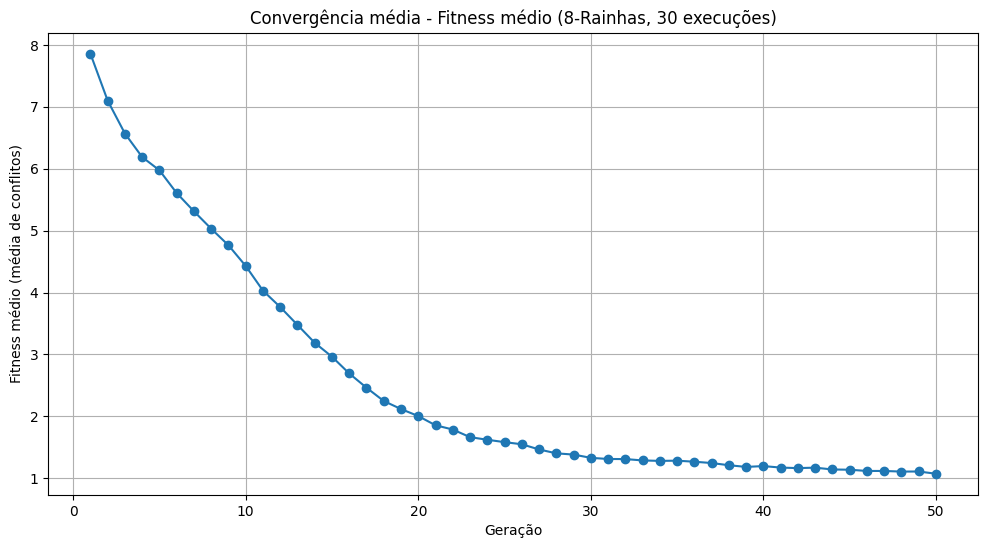

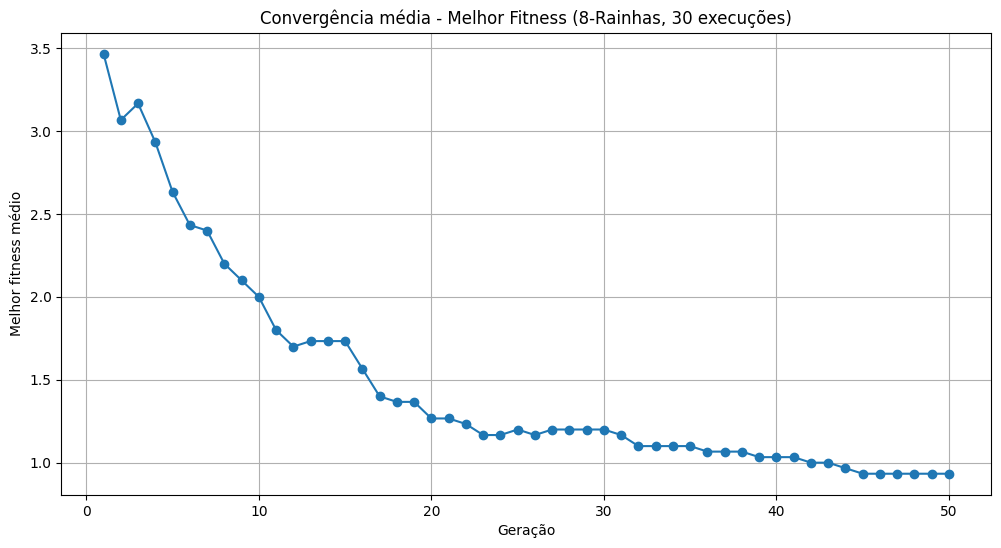

In [7]:
tempos = [r["tempo_execucao"] for r in resultados_execucoes]
geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]

tempo_medio = np.mean(tempos)
geracoes_medias = np.mean(geracoes_conv)
melhor_fitness_medio = np.mean(melhores_finais)

print("===== TABELA RESUMO =====")
print(f"n = 8")
print(f"Tempo médio de execução: {tempo_medio:.4f} s")
print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")

# -------------------------------------------------------------------------------------

historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

media_das_medias = np.mean(historicos_media, axis=0)
media_dos_melhores = np.mean(historicos_melhor, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_das_medias) + 1), media_das_medias, marker='o')
plt.xlabel('Geração')
plt.ylabel('Fitness médio (média de conflitos)')
plt.title(f'Convergência média - Fitness médio ({n}-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_dos_melhores) + 1), media_dos_melhores, marker='o')
plt.xlabel('Geração')
plt.ylabel('Melhor fitness médio')
plt.title(f'Convergência média - Melhor Fitness ({n}-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

In [8]:
melhor_execucao = min(resultados_execucoes, key=lambda r: r["melhor_conflito_global"])
melhor_individuo = melhor_execucao["melhor_individuo_global"]

print("===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====")
print(f"Melhor conflito: {melhor_execucao['melhor_conflito_global']}")
print(f"Geração em que apareceu: {melhor_execucao['melhor_geracao_global']}")
print(f"Indivíduo: {melhor_individuo}")

imprime_tabuleiro(melhor_individuo)

===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====
Melhor conflito: 0
Geração em que apareceu: 31
Indivíduo: [3 5 7 1 4 2 8 6]

TABULEIRO DA MELHOR SOLUÇÃO:

 .  .  .  Q  .  .  .  . 
 .  .  .  .  .  Q  .  . 
 Q  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 


## Para 50 indivíduos, 15 rainhas e 50 gerações

In [9]:
num_execucoes = 30
resultados_execucoes = []

for execucao in range(num_execucoes):
    print(f"Executando experimento {execucao + 1}/{num_execucoes}...")
    resultado = executar_queens(m=50, n=15, geracoes=50, taxa_mutacao=0.05)
    resultados_execucoes.append(resultado)

print("\nTodas as execuções concluídas.")

Executando experimento 1/30...
Executando experimento 2/30...
Executando experimento 3/30...
Executando experimento 4/30...
Executando experimento 5/30...
Executando experimento 6/30...
Executando experimento 7/30...
Executando experimento 8/30...
Executando experimento 9/30...
Executando experimento 10/30...
Executando experimento 11/30...
Executando experimento 12/30...
Executando experimento 13/30...
Executando experimento 14/30...
Executando experimento 15/30...
Executando experimento 16/30...
Executando experimento 17/30...
Executando experimento 18/30...
Executando experimento 19/30...
Executando experimento 20/30...
Executando experimento 21/30...
Executando experimento 22/30...
Executando experimento 23/30...
Executando experimento 24/30...
Executando experimento 25/30...
Executando experimento 26/30...
Executando experimento 27/30...
Executando experimento 28/30...
Executando experimento 29/30...
Executando experimento 30/30...

Todas as execuções concluídas.


===== TABELA RESUMO =====
n = 15
Tempo médio de execução: 0.1855 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 2.90


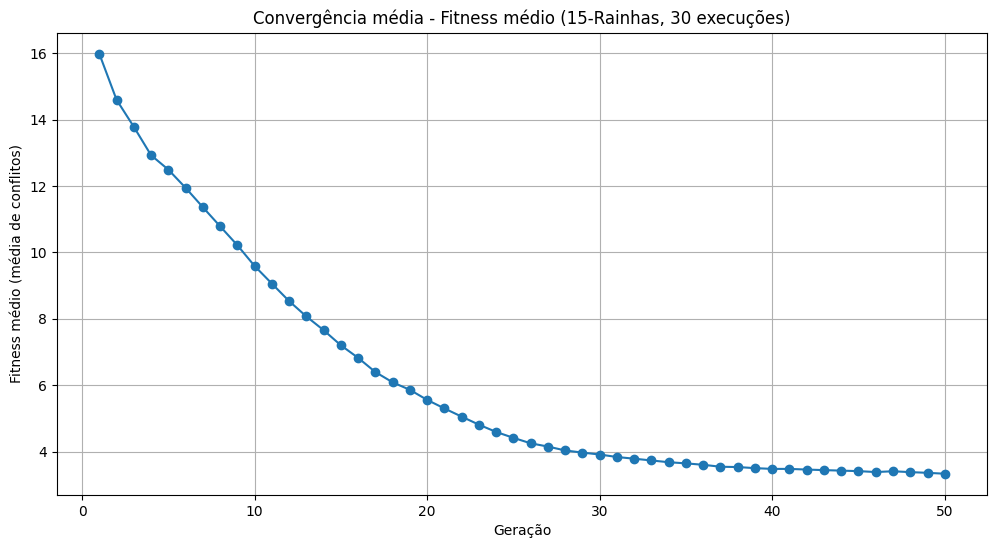

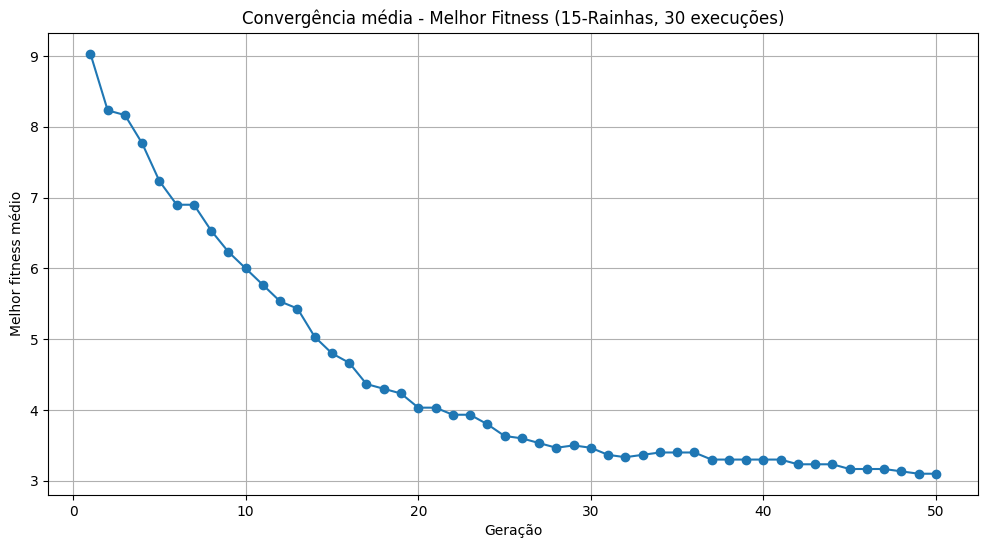

In [11]:
tempos = [r["tempo_execucao"] for r in resultados_execucoes]
geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]

tempo_medio = np.mean(tempos)
geracoes_medias = np.mean(geracoes_conv)
melhor_fitness_medio = np.mean(melhores_finais)

print("===== TABELA RESUMO =====")
print(f"n = 15")
print(f"Tempo médio de execução: {tempo_medio:.4f} s")
print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")

# -------------------------------------------------------------------------------------

historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

media_das_medias = np.mean(historicos_media, axis=0)
media_dos_melhores = np.mean(historicos_melhor, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_das_medias) + 1), media_das_medias, marker='o')
plt.xlabel('Geração')
plt.ylabel('Fitness médio (média de conflitos)')
plt.title(f'Convergência média - Fitness médio (15-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_dos_melhores) + 1), media_dos_melhores, marker='o')
plt.xlabel('Geração')
plt.ylabel('Melhor fitness médio')
plt.title(f'Convergência média - Melhor Fitness (15-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

In [12]:
melhor_execucao = min(resultados_execucoes, key=lambda r: r["melhor_conflito_global"])
melhor_individuo = melhor_execucao["melhor_individuo_global"]

print("===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====")
print(f"Melhor conflito: {melhor_execucao['melhor_conflito_global']}")
print(f"Geração em que apareceu: {melhor_execucao['melhor_geracao_global']}")
print(f"Indivíduo: {melhor_individuo}")

imprime_tabuleiro(melhor_individuo)

===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====
Melhor conflito: 1
Geração em que apareceu: 25
Indivíduo: [ 8  3 14  7  5 15 13 10  4  9  5  2 11  1 12]

TABULEIRO DA MELHOR SOLUÇÃO:

 .  .  .  .  .  .  .  .  .  .  .  .  .  Q  . 
 .  .  .  .  .  .  .  .  .  .  .  Q  .  .  . 
 .  Q  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  Q  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  .  .  .  Q  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  Q  .  .  .  .  .  .  .  .  .  .  . 
 Q  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  .  Q  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  Q  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q 
 .  .  .  .  .  .  Q  .  .  .  .  .  .  .  . 
 .  .  Q  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  Q  .  .  .  .  .  .  .  .  . 


## Para 50 indivíduos, 20 rainhas, 50 gerações

In [13]:
num_execucoes = 30
resultados_execucoes = []

for execucao in range(num_execucoes):
    print(f"Executando experimento {execucao + 1}/{num_execucoes}...")
    resultado = executar_queens(m=50, n=20, geracoes=50, taxa_mutacao=0.05)
    resultados_execucoes.append(resultado)

print("\nTodas as execuções concluídas.")

Executando experimento 1/30...
Executando experimento 2/30...
Executando experimento 3/30...
Executando experimento 4/30...
Executando experimento 5/30...
Executando experimento 6/30...
Executando experimento 7/30...
Executando experimento 8/30...
Executando experimento 9/30...
Executando experimento 10/30...
Executando experimento 11/30...
Executando experimento 12/30...
Executando experimento 13/30...
Executando experimento 14/30...
Executando experimento 15/30...
Executando experimento 16/30...
Executando experimento 17/30...
Executando experimento 18/30...
Executando experimento 19/30...
Executando experimento 20/30...
Executando experimento 21/30...
Executando experimento 22/30...
Executando experimento 23/30...
Executando experimento 24/30...
Executando experimento 25/30...
Executando experimento 26/30...
Executando experimento 27/30...
Executando experimento 28/30...
Executando experimento 29/30...
Executando experimento 30/30...

Todas as execuções concluídas.


===== TABELA RESUMO =====
n = 20
Tempo médio de execução: 0.3157 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 4.87


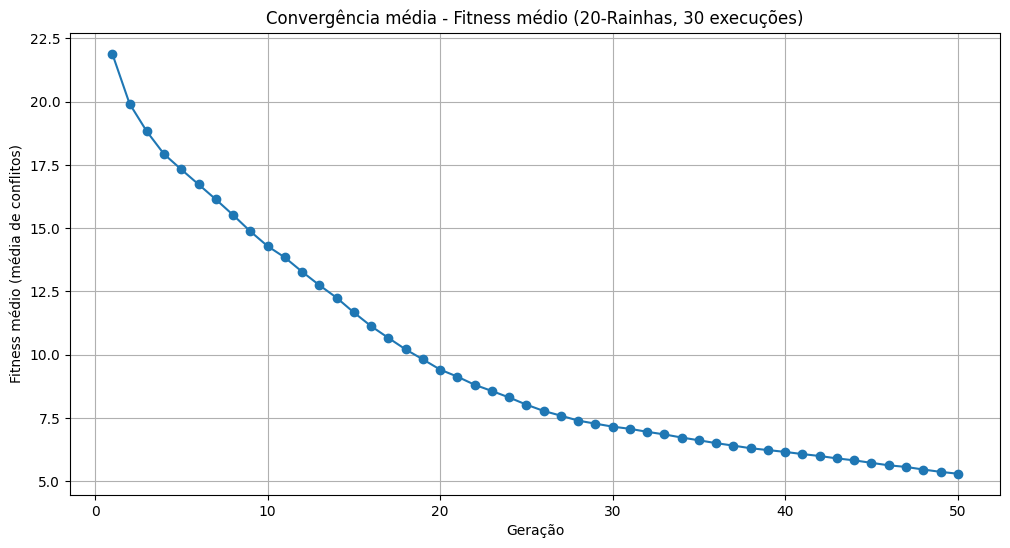

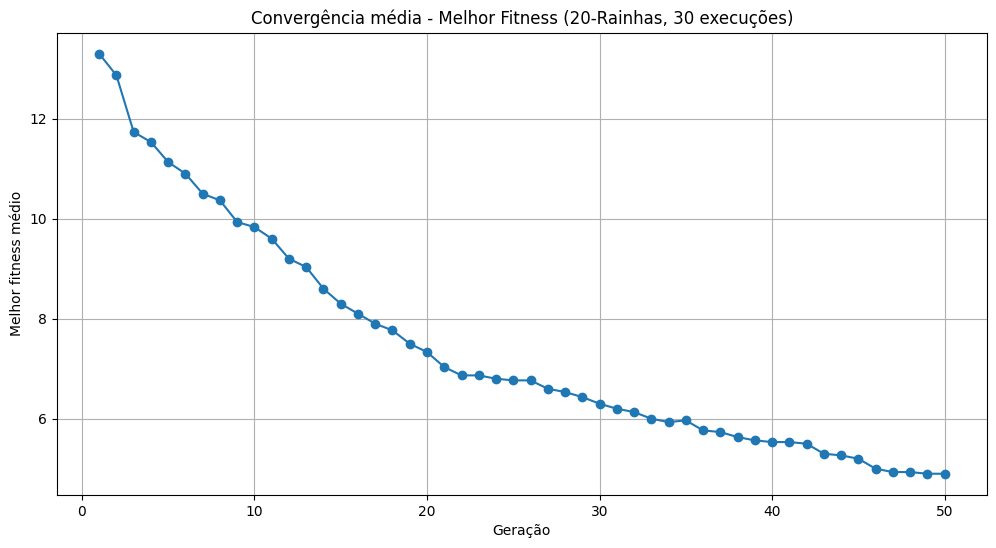

In [14]:
tempos = [r["tempo_execucao"] for r in resultados_execucoes]
geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]

tempo_medio = np.mean(tempos)
geracoes_medias = np.mean(geracoes_conv)
melhor_fitness_medio = np.mean(melhores_finais)

print("===== TABELA RESUMO =====")
print(f"n = 20")
print(f"Tempo médio de execução: {tempo_medio:.4f} s")
print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")

# -------------------------------------------------------------------------------------

historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

media_das_medias = np.mean(historicos_media, axis=0)
media_dos_melhores = np.mean(historicos_melhor, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_das_medias) + 1), media_das_medias, marker='o')
plt.xlabel('Geração')
plt.ylabel('Fitness médio (média de conflitos)')
plt.title(f'Convergência média - Fitness médio (20-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_dos_melhores) + 1), media_dos_melhores, marker='o')
plt.xlabel('Geração')
plt.ylabel('Melhor fitness médio')
plt.title(f'Convergência média - Melhor Fitness (20-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

In [15]:
melhor_execucao = min(resultados_execucoes, key=lambda r: r["melhor_conflito_global"])
melhor_individuo = melhor_execucao["melhor_individuo_global"]

print("===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====")
print(f"Melhor conflito: {melhor_execucao['melhor_conflito_global']}")
print(f"Geração em que apareceu: {melhor_execucao['melhor_geracao_global']}")
print(f"Indivíduo: {melhor_individuo}")

imprime_tabuleiro(melhor_individuo)

===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====
Melhor conflito: 2
Geração em que apareceu: 43
Indivíduo: [12 15  6 11  5  8  4 14  3 20 19 13 18 10  1  7  2 17  9 16]

TABULEIRO DA MELHOR SOLUÇÃO:

 .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  . 
 .  .  .  .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  . 
 .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  .  .  . 
 .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  .  .  .  .  . 

## Para 50 indivíduos, 30 rainhas, 50 gerações

In [16]:
num_execucoes = 30
resultados_execucoes = []

for execucao in range(num_execucoes):
    print(f"Executando experimento {execucao + 1}/{num_execucoes}...")
    resultado = executar_queens(m=50, n=30, geracoes=50, taxa_mutacao=0.05)
    resultados_execucoes.append(resultado)

print("\nTodas as execuções concluídas.")

Executando experimento 1/30...
Executando experimento 2/30...
Executando experimento 3/30...
Executando experimento 4/30...
Executando experimento 5/30...
Executando experimento 6/30...
Executando experimento 7/30...
Executando experimento 8/30...
Executando experimento 9/30...
Executando experimento 10/30...
Executando experimento 11/30...
Executando experimento 12/30...
Executando experimento 13/30...
Executando experimento 14/30...
Executando experimento 15/30...
Executando experimento 16/30...
Executando experimento 17/30...
Executando experimento 18/30...
Executando experimento 19/30...
Executando experimento 20/30...
Executando experimento 21/30...
Executando experimento 22/30...
Executando experimento 23/30...
Executando experimento 24/30...
Executando experimento 25/30...
Executando experimento 26/30...
Executando experimento 27/30...
Executando experimento 28/30...
Executando experimento 29/30...
Executando experimento 30/30...

Todas as execuções concluídas.


===== TABELA RESUMO =====
n = 30
Tempo médio de execução: 0.6682 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 9.60


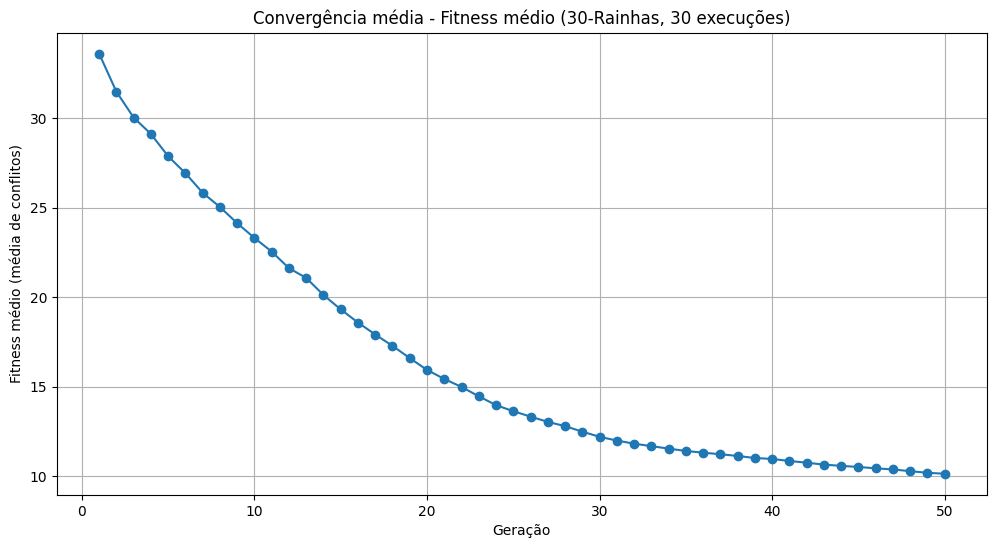

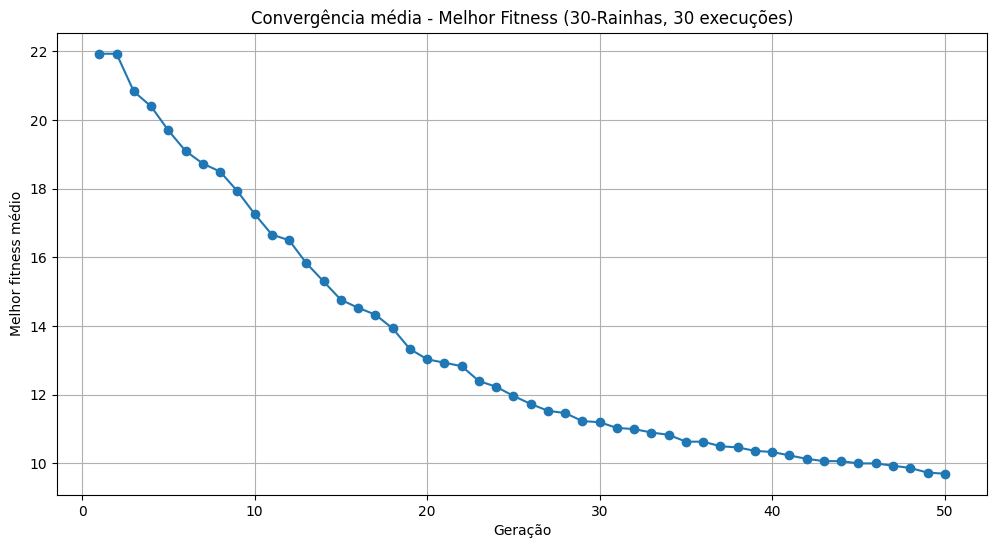

In [18]:
tempos = [r["tempo_execucao"] for r in resultados_execucoes]
geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]

tempo_medio = np.mean(tempos)
geracoes_medias = np.mean(geracoes_conv)
melhor_fitness_medio = np.mean(melhores_finais)

print("===== TABELA RESUMO =====")
print(f"n = 30")
print(f"Tempo médio de execução: {tempo_medio:.4f} s")
print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")

# -------------------------------------------------------------------------------------

historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

media_das_medias = np.mean(historicos_media, axis=0)
media_dos_melhores = np.mean(historicos_melhor, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_das_medias) + 1), media_das_medias, marker='o')
plt.xlabel('Geração')
plt.ylabel('Fitness médio (média de conflitos)')
plt.title(f'Convergência média - Fitness médio (30-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(media_dos_melhores) + 1), media_dos_melhores, marker='o')
plt.xlabel('Geração')
plt.ylabel('Melhor fitness médio')
plt.title(f'Convergência média - Melhor Fitness (30-Rainhas, {num_execucoes} execuções)')
plt.grid(True)
plt.show()

In [19]:
melhor_execucao = min(resultados_execucoes, key=lambda r: r["melhor_conflito_global"])
melhor_individuo = melhor_execucao["melhor_individuo_global"]

print("===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====")
print(f"Melhor conflito: {melhor_execucao['melhor_conflito_global']}")
print(f"Geração em que apareceu: {melhor_execucao['melhor_geracao_global']}")
print(f"Indivíduo: {melhor_individuo}")

imprime_tabuleiro(melhor_individuo)

===== MELHOR SOLUÇÃO ENCONTRADA ENTRE AS EXECUÇÕES =====
Melhor conflito: 7
Geração em que apareceu: 49
Indivíduo: [10 25 23 13  1  3 14  8  4 27 24 11 19 28  4  2  7 16 29 21 18  3 26  6
  9 30 20 15 23 15]

TABULEIRO DA MELHOR SOLUÇÃO:

 .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  Q  .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  Q  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  . 